#S.Langa 22522719<br>
</br>#S.SHELEMBE 22506130<br>
</br>#SI NUTLI 22404967<br>
 </br># NM Nzama 22510310

# ***RFM-Data Analysis Based on the Jupyter Notebook -2026-0414***

---

# Content
We learn something from the perspectives of resolveing the practical problems. 
>1. Basic manipulation (Markdown) of Jupyter Notebook
>2. RFM Concept
>3. Data Anylasis
    > 1. Data Import
    > 2. Sorting
    > 3. Merging
    > 4. Computing

>4. Visulization

# Basic manipulation (Markdown) of Jupyter Notebook

Some practice

# RFM

## ***Background***

![RFM.png](RFM1.png)

## A very important concept or marketing
***Classification (Customer Segmentation) based on RFM***<br>
RFM is a method used for analyzing customer value and segmenting customers which is commonly used in database marketing and direct marketing. 
It has received particular attention in the retail and professional services industries.

***RFM stands for the three dimensions:***
 - Recency – How recently did the customer purchase?
 - Frequency – How often do they purchase?
 - Monetary Value – How much do they spend?

## Application  Senarios
RFM is suitable for industries such as securities, internet, retail, e-commerce, telecommunications, travel, and catering. It is particularly applicable to companies or industries where monetary value and transaction frequency carry significant weight.

1.  Blockchain company
2.  Requirement: Extract high-value customers to facilitate business and marketing operations
3.  Company database: Outsourced
4.  Company's main business: Digital currency


RFM is suitable for industries such as securities, internet, retail, e-commerce, telecommunications, travel, and catering. It is particularly applicable to companies or industries where monetary value and transaction frequency carry significant weight.


---

## <font color='salmon'>Why RFM Model？</font>
**The RFM model has three advantages**
1. **Low data source requirements**. The model only requires data from 4 fields, making data acquisition relatively easy.
2. **Easy to use and quick to master**. The model has low complexity in setup, allowing even business departments to independently build and maintain it.
3. **Intuitive and clear**. The model has strong interpretability, and its segmentation results are easily understood and accepted by business personnel.


---

## **This model can help answer the following customer questions**
1. Who are my best customers?
2. Who are my loyal customers?
3. Which customers are churning?
4. Which customers do I need to win back?
5. Which customers have low value and don't require much attention?

## <font color='salmon'>How to Use the Results Produced by the RFM Model？</font>

1. The model ultimately needs to assign a classification tier to each evaluated user and provide corresponding solutions
2. Traditional response solutions corresponding to each customer tier


![rfmmetric.png](m1.png)

![rfmmetric.jpg](rfmmetric.jpg)

<img src="rfm-l.png">

# The Modeling Process of the RFM Model - Data Anylasis




## <font color='darkred'>Step 1: Prepare Raw Data</font>

---

### Data Required:
•  Customer Unique Identifier (ID)

•  Recency (R): Date of most recent transaction

•  Frequency (F): Transaction frequency

•  Monetary (M): Transaction amount

## <font color='darkgreen'>Step 2: Binning to Obtain R, F, and M Scores</font>

---

1.Binning refers to the process of setting scoring rules for the R, F, and M fields obtained in Step 1, and deriving corresponding scores based on those rules.

2.The score ranges can be adjusted according to the actual data situation.

3.Here we demonstrate using the fixed range method: this method is more suitable when the data volume is small or data quality is suboptimal.

<img src="RFM-Binning.png">

## <font color='cadetblue'>Step 3: Calculate Reference Values</font>

After obtaining the scores for R, F, and M, we need to derive their respective reference values in preparation for calculating the comparison values in the next step.


## <font color='cadetblue'>Step 4: Calculate Comparison Values
</font>

After obtaining the reference values for R, F, and M, compare them with the corresponding data for each user. Assign 1 if greater than the reference value, otherwise assign 0.

## <font color='cadetblue'>Step 5: Obtain Segmentation Results Based on Mapping Relationships
</font>

After obtaining the comparison values for R, F, and M, proceed to segment customers based on the following mapping rules.

<img src="RF LEVEL.png">

# **Data Analysis Practice** - The Specific Implementation Process of the RFM Model

---

## Task 1: Data Import and Exploration

### Import the necessary libraries for data analysis

In [1]:
import pandas as pd

In [2]:
shuju=pd.read_excel('data.xlsx')

### **Data Exploration**

In [3]:
shuju.head()

,QTY,Amount,BuyerID,Currency,SellerID,Entrustment Type,aa,bb,Time
0,119.19970,973.670829,1856606,USDT,2060525,BUY,NaN,2060525.0,2019-12-11
1,94.00000,768.685000,1856606,USDT,2060525,BUY,NaN,2060525.0,2019-12-11
2,451.00000,3691.660500,1856606,USDT,2060525,BUY,NaN,2060525.0,2019-12-11
3,25.98788,212.983670,1856606,USDT,2060525,BUY,NaN,2060525.0,2019-12-11
4,5.00000,40.829000,1856168,USDT,2060525,BUY,NaN,2060525.0,2019-12-11


In [4]:
shuju.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21265 entries, 0 to 21264
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   QTY               21265 non-null  float64       
 1   Amount            21265 non-null  float64       
 2   BuyerID           21265 non-null  int64         
 3   Currency          21265 non-null  object        
 4   SellerID          21265 non-null  int64         
 5   Entrustment Type  21265 non-null  object        
 6   aa                4363 non-null   float64       
 7   bb                10162 non-null  float64       
 8   Time              21265 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(4), int64(2), object(2)
memory usage: 1.5+ MB


In [5]:
shuju.aa.value_counts()

aa
2062344.0    2336
2060701.0    1195
2060525.0     438
2060714.0     365
1856655.0      27
12345.0         1
1857269.0       1
Name: count, dtype: int64

In [6]:
shuju.bb.value_counts()

bb
2060525.0    5543
2060701.0    3677
2060714.0     582
2062344.0     269
1856655.0      91
Name: count, dtype: int64

### Data Cleaning and Processing

#### Filter out all rows where Currency is USDT, and column aa is empty, and column bb is empty → save them as a new clean table qx_shuju.

In [7]:
qx_shuju=shuju.loc[(shuju.Currency=='USDT') &(shuju.aa.isnull()) &(shuju.bb.isnull())]

In [8]:
qx_shuju

,QTY,Amount,BuyerID,Currency,SellerID,Entrustment Type,aa,bb,Time
11,2.000000,16.301000,2358204,USDT,1856168,SELL,NaN,NaN,2019-12-11
21,564.157700,4626.093140,1856613,USDT,2498710,BUY,NaN,NaN,2019-12-11
23,6.000000,48.994800,2475382,USDT,2498710,SELL,NaN,NaN,2019-12-11
24,2.508100,20.480392,2354081,USDT,2498710,SELL,NaN,NaN,2019-12-11
25,23.971900,195.747344,2110674,USDT,2498710,SELL,NaN,NaN,2019-12-11
...,...,...,...,...,...,...,...,...,...
20276,900.000000,7196.040000,2597139,USDT,3572858,BUY,NaN,NaN,2019-12-01
20277,862.186700,6893.699979,3551047,USDT,3572858,BUY,NaN,NaN,2019-12-01
20278,646.758600,5171.223062,3551047,USDT,3572858,BUY,NaN,NaN,2019-12-01
20281,1738.735197,13902.231144,1854161,USDT,3572858,BUY,NaN,NaN,2019-12-01


In [9]:
qx_shuju.dropna(axis=1,how='all')
#axis=1 is target column

,QTY,Amount,BuyerID,Currency,SellerID,Entrustment Type,Time
11,2.000000,16.301000,2358204,USDT,1856168,SELL,2019-12-11
21,564.157700,4626.093140,1856613,USDT,2498710,BUY,2019-12-11
23,6.000000,48.994800,2475382,USDT,2498710,SELL,2019-12-11
24,2.508100,20.480392,2354081,USDT,2498710,SELL,2019-12-11
25,23.971900,195.747344,2110674,USDT,2498710,SELL,2019-12-11
...,...,...,...,...,...,...,...
20276,900.000000,7196.040000,2597139,USDT,3572858,BUY,2019-12-01
20277,862.186700,6893.699979,3551047,USDT,3572858,BUY,2019-12-01
20278,646.758600,5171.223062,3551047,USDT,3572858,BUY,2019-12-01
20281,1738.735197,13902.231144,1854161,USDT,3572858,BUY,2019-12-01


### <font color='salmon'>Preparing Indicator Data for R, F, and M</font>

* Filter the columns of 'BuyerID','Amount','QTY' of your cleaned data table qx_shuju, groups all data by Buyer ID, and saves the grouped dataset into a new variable named F_M

In [10]:
F_M=qx_shuju.loc[:,['BuyerID','Amount','QTY']].groupby(by='BuyerID')

In [11]:
F_M.head()

,BuyerID,Amount,QTY
11,2358204,16.301000,2.000000
21,1856613,4626.093140,564.157700
23,2475382,48.994800,6.000000
24,2354081,20.480392,2.508100
25,2110674,195.747344,23.971900
...,...,...,...
20233,1860150,460.539610,57.893100
20270,2448438,10.037790,1.260000
20275,2448438,21987.176419,2749.909503
20276,2597139,7196.040000,900.000000


In [12]:
#reset index function ew
F_M.head().reset_index()


,index,BuyerID,Amount,QTY
0,11,2358204,16.301000,2.000000
1,21,1856613,4626.093140,564.157700
2,23,2475382,48.994800,6.000000
3,24,2354081,20.480392,2.508100
4,25,2110674,195.747344,23.971900
...,...,...,...,...
1275,20233,1860150,460.539610,57.893100
1276,20270,2448438,10.037790,1.260000
1277,20275,2448438,21987.176419,2749.909503
1278,20276,2597139,7196.040000,900.000000


* Calculate key statistics for every buyer from the grouped data F_M, then creates a clean, final DataFrame named f_m that shows each buyer's total orders and total spending.

In [13]:
f_m=F_M.agg({'QTY':'count','Amount':'sum'}).reset_index()

In [14]:
f_m

,BuyerID,QTY,Amount
0,1841783,1,29.038564
1,1844162,1,8484.625000
2,1852621,3,6910.572248
3,1853814,1,1488.160973
4,1854075,3,6380.078954
...,...,...,...
462,3744845,2,5915.556300
463,3746120,2,1813.423289
464,3748065,1,4.929172
465,3759056,2,2707.974874


* Sort the DataFrame f_m in ascending order (from smallest to largest) based on the values in the QTY column.

In [15]:
f_m.sort_values(by='QTY')

,BuyerID,QTY,Amount
0,1841783,1,29.038564
1,1844162,1,8484.625000
24,1856818,1,8812.670750
29,1861024,1,2469.185300
30,1872769,1,737.813013
...,...,...,...
7,1854710,42,24598.665105
258,2473240,43,49936.182351
253,2469015,55,246025.122372
244,2460735,146,498036.222829


* Sort the DataFrame f_m in ascending order (from largest to smallest) based on the values in the QTY column.

In [16]:
f_m.sort_values(by='QTY',ascending=False)

,BuyerID,QTY,Amount
456,3737933,211,3418.296598
244,2460735,146,498036.222829
253,2469015,55,246025.122372
258,2473240,43,49936.182351
7,1854710,42,24598.665105
...,...,...,...
438,3625256,1,3298.162978
440,3625483,1,442.860274
439,3625351,1,30.954060
444,3628632,1,1681.972250


# Getting ready for the Model

* Filter all transaction records for a SPECIFIC buyer (ID: 1854710) from the original data table shuju, and then sorts these records from the NEWEST to the OLDEST based on the transaction time.

In [17]:
shuju.loc[shuju.BuyerID==1854710].sort_values(by='Time',ascending=False)

,QTY,Amount,BuyerID,Currency,SellerID,Entrustment Type,aa,bb,Time
3754,28.9800,235.045188,1854710,USDT,2496109,SELL,NaN,NaN,2019-12-13
3301,59.4911,482.633447,1854710,USDT,3633721,BUY,NaN,NaN,2019-12-13
3108,30.9859,251.915367,1854710,USDT,2060525,BUY,NaN,2060525.0,2019-12-13
3176,127.8786,1039.064776,1854710,USDT,3744190,SELL,NaN,NaN,2019-12-13
3180,0.3580,2.910361,1854710,USDT,2060525,BUY,NaN,2060525.0,2019-12-13
...,...,...,...,...,...,...,...,...,...
20087,247.1579,1961.766400,1854710,USDT,3598571,BUY,NaN,NaN,2019-12-01
21025,36967.9654,5885.300092,1854710,BTH,2060701,BUY,NaN,2060701.0,2019-12-01
21235,28676.0131,4685.660541,1854710,BTH,2060701,BUY,NaN,2060701.0,2019-12-01
21236,1938.6191,317.158085,1854710,BTH,2060701,BUY,NaN,2060701.0,2019-12-01


* Extract the LATEST transaction time for each unique buyer from the filtered table qx_shuju, and stores the clean result (Buyer ID + Last Transaction Time) into a new DataFrame named r.

In [18]:
qx_shuju.head()

,QTY,Amount,BuyerID,Currency,SellerID,Entrustment Type,aa,bb,Time
11,2.0000,16.301000,2358204,USDT,1856168,SELL,NaN,NaN,2019-12-11
21,564.1577,4626.093140,1856613,USDT,2498710,BUY,NaN,NaN,2019-12-11
23,6.0000,48.994800,2475382,USDT,2498710,SELL,NaN,NaN,2019-12-11
24,2.5081,20.480392,2354081,USDT,2498710,SELL,NaN,NaN,2019-12-11
25,23.9719,195.747344,2110674,USDT,2498710,SELL,NaN,NaN,2019-12-11


In [19]:
r=qx_shuju.loc[:,['BuyerID','Time']].groupby(by='BuyerID').max().reset_index()
#: means all the lines in that column
#maximum of each value in the group

In [20]:
r

,BuyerID,Time
0,1841783,2019-12-10
1,1844162,2019-12-10
2,1852621,2019-12-01
3,1853814,2019-12-08
4,1854075,2019-12-07
...,...,...
462,3744845,2019-12-13
463,3746120,2019-12-13
464,3748065,2019-12-13
465,3759056,2019-12-13


* Merge (join) two separate DataFrames (r and f_m) into one single, complete table named rfm by matching the BuyerID column.<br>
It combines the buyer's latest transaction time (from table r) and the buyer's order count & total spending (from table f_m) into one unified table.


In [21]:
rfm=pd.merge(r,f_m,how='inner',on=['BuyerID'])

In [22]:
rfm

,BuyerID,Time,QTY,Amount
0,1841783,2019-12-10,1,29.038564
1,1844162,2019-12-10,1,8484.625000
2,1852621,2019-12-01,3,6910.572248
3,1853814,2019-12-08,1,1488.160973
4,1854075,2019-12-07,3,6380.078954
...,...,...,...,...
462,3744845,2019-12-13,2,5915.556300
463,3746120,2019-12-13,2,1813.423289
464,3748065,2019-12-13,1,4.929172
465,3759056,2019-12-13,2,2707.974874


*  Filter and displays ONLY the data for the SPECIFIC buyer with ID 1854710 from the merged rfm DataFrame.

In [23]:
rfm.loc[rfm.BuyerID==1854710]

,BuyerID,Time,QTY,Amount
7,1854710,2019-12-13,42,24598.665105


* calculates the Recency (R) value (a key metric in customer RFM analysis) and creates a new column named RIndex in the rfm DataFrame.
The RIndex stores the number of days between the customer’s LAST purchase and the fixed analysis date (2019-12-15).

In [24]:
rfm['RIndex']=(pd.to_datetime('2019-12-15')-rfm['Time']).dt.days

In [25]:
rfm

,BuyerID,Time,QTY,Amount,RIndex
0,1841783,2019-12-10,1,29.038564,5
1,1844162,2019-12-10,1,8484.625000,5
2,1852621,2019-12-01,3,6910.572248,14
3,1853814,2019-12-08,1,1488.160973,7
4,1854075,2019-12-07,3,6380.078954,8
...,...,...,...,...,...
462,3744845,2019-12-13,2,5915.556300,2
463,3746120,2019-12-13,2,1813.423289,2
464,3748065,2019-12-13,1,4.929172,2
465,3759056,2019-12-13,2,2707.974874,2


* keeps all the core data required for RFM customer analysis and removes all unnecessary extra columns.

Action: Extract only the 4 most critical columns from the merged rfm table and place them into a new variable.
Purpose: To discard unnecessary intermediate data (such as the original Time column) and retain only the core data required for the metrics.

In [26]:
RFM=rfm.loc[:,['BuyerID','QTY','Amount','RIndex']]

In [27]:
RFM

,BuyerID,QTY,Amount,RIndex
0,1841783,1,29.038564,5
1,1844162,1,8484.625000,5
2,1852621,3,6910.572248,14
3,1853814,1,1488.160973,7
4,1854075,3,6380.078954,8
...,...,...,...,...
462,3744845,2,5915.556300,2
463,3746120,2,1813.423289,2
464,3748065,1,4.929172,2
465,3759056,2,2707.974874,2


In [28]:
RFM.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 467 entries, 0 to 466
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   BuyerID  467 non-null    int64  
 1   QTY      467 non-null    int64  
 2   Amount   467 non-null    float64
 3   RIndex   467 non-null    int64  
dtypes: float64(1), int64(3)
memory usage: 14.7 KB


* Change the original generic column names to dedicated labels that match the R (Recency), F (Frequency), M (Monetary) model.

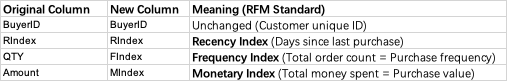

In [29]:
RFM.columns=['BuyerID','FIndex','MIndex','RIndex']

In [30]:
RFM

,BuyerID,FIndex,MIndex,RIndex
0,1841783,1,29.038564,5
1,1844162,1,8484.625000,5
2,1852621,3,6910.572248,14
3,1853814,1,1488.160973,7
4,1854075,3,6380.078954,8
...,...,...,...,...
462,3744845,2,5915.556300,2
463,3746120,2,1813.423289,2
464,3748065,1,4.929172,2
465,3759056,2,2707.974874,2


# <font color='red'>Build the Model
</font>

* 1. Let's work on Findex

In [31]:
RFM.FIndex.value_counts()

FIndex
1      161
2       90
3       51
4       39
5       22
6       21
7       17
8       11
9        7
11       6
12       5
10       4
16       3
13       3
32       3
28       3
25       2
18       2
20       2
17       2
14       2
42       1
22       1
15       1
24       1
23       1
26       1
146      1
55       1
43       1
19       1
211      1
Name: count, dtype: int64

In [32]:
def F(x):
    if x <= 2:
        return 1
    elif x <= 6:
        return 2
    elif x <= 20:
        return 3
    elif x <= 40:
        return 4
    else:
        return 5

In [33]:
RFM['FValue']=RFM['FIndex'].apply(F)

In [34]:
RFM

,BuyerID,FIndex,MIndex,RIndex,FValue
0,1841783,1,29.038564,5,1
1,1844162,1,8484.625000,5,1
2,1852621,3,6910.572248,14,2
3,1853814,1,1488.160973,7,1
4,1854075,3,6380.078954,8,2
...,...,...,...,...,...
462,3744845,2,5915.556300,2,1
463,3746120,2,1813.423289,2,1
464,3748065,1,4.929172,2,1
465,3759056,2,2707.974874,2,1


* 2. Let's work on Rindex

In [35]:
def R(x):
    if x <= 2:
        return 1
    elif x <= 4:
        return 2
    elif x <= 6:
        return 3
    elif x <= 10:
        return 4
    else:
        return 5

In [36]:
RFM['RValue']=RFM['RIndex'].apply(R)

In [37]:
RFM

,BuyerID,FIndex,MIndex,RIndex,FValue,RValue
0,1841783,1,29.038564,5,1,3
1,1844162,1,8484.625000,5,1,3
2,1852621,3,6910.572248,14,2,5
3,1853814,1,1488.160973,7,1,4
4,1854075,3,6380.078954,8,2,4
...,...,...,...,...,...,...
462,3744845,2,5915.556300,2,1,1
463,3746120,2,1813.423289,2,1,1
464,3748065,1,4.929172,2,1,1
465,3759056,2,2707.974874,2,1,1


* 3. Let's work on Mindex

In [38]:
def M(x):
    if x <= 100:
        return 1
    elif x <= 500:
        return 2
    elif x <= 2000:
        return 3
    elif x <= 10000:
        return 4
    else:
        return 5

In [39]:
RFM['MValue']=RFM['MIndex'].apply(M)

In [40]:
RFM

,BuyerID,FIndex,MIndex,RIndex,FValue,RValue,MValue
0,1841783,1,29.038564,5,1,3,1
1,1844162,1,8484.625000,5,1,3,4
2,1852621,3,6910.572248,14,2,5,4
3,1853814,1,1488.160973,7,1,4,3
4,1854075,3,6380.078954,8,2,4,4
...,...,...,...,...,...,...,...
462,3744845,2,5915.556300,2,1,1,4
463,3746120,2,1813.423289,2,1,1,3
464,3748065,1,4.929172,2,1,1,1
465,3759056,2,2707.974874,2,1,1,4


# Calculate Comparison Values
After obtaining the reference values for R, F, and M, compare them with the corresponding data for each user. Assign 1 if greater than the reference value, otherwise assign 0.

In [41]:
RFM['RComp']=RFM['RValue'].apply(lambda x:0 if x<=RFM['RValue'].mean() else 1)
RFM['FComp']=RFM['FValue'].apply(lambda x:0 if x<=RFM['FValue'].mean() else 1)
RFM['MComp']=RFM['MValue'].apply(lambda x:0 if x<=RFM['MValue'].mean() else 1)
RFM

,BuyerID,FIndex,MIndex,RIndex,FValue,RValue,MValue,RComp,FComp,MComp
0,1841783,1,29.038564,5,1,3,1,1,0,0
1,1844162,1,8484.625000,5,1,3,4,1,0,1
2,1852621,3,6910.572248,14,2,5,4,1,1,1
3,1853814,1,1488.160973,7,1,4,3,1,0,0
4,1854075,3,6380.078954,8,2,4,4,1,1,1
...,...,...,...,...,...,...,...,...,...,...
462,3744845,2,5915.556300,2,1,1,4,0,0,1
463,3746120,2,1813.423289,2,1,1,3,0,0,0
464,3748065,1,4.929172,2,1,1,1,0,0,0
465,3759056,2,2707.974874,2,1,1,4,0,0,1


* Let's get the RFM table

<img src="RF LEVEL.png">

* Custom RFM customer segmentation function.<br>
It takes three 0/1 flags (x, y, z) and returns a clear customer type label based on their Recency, Frequency, and Monetary behavior.

In [42]:
def panduan(x, y, z):
    if x == 1 and y == 1 and z == 1:
        return 'High-Value Customers'
    
    elif x == 1 and y == 1 and z == 0:
    
        return 'Potential Customers'
    elif x==0 and y==1 and z==1:
        return 'High-value-AT RISK'
    
    elif x == 1 and y == 0 and z == 1:
        return 'High-Potential Customers'
    
    elif x == 0 and y == 0 and z == 1:
        return 'Customers to Retain'
    
    elif x == 1 and y == 0 and z == 0:
        return 'New Customers'
    
    elif x == 0 and y == 1 and z == 0:
        return 'Regular Customers'
    
    else:
        return 'Lost Customers'

In [43]:
#check the columns in data
print(RFM.columns)


Index(['BuyerID', 'FIndex', 'MIndex', 'RIndex', 'FValue', 'RValue', 'MValue',
       'RComp', 'FComp', 'MComp'],
      dtype='object')


In [44]:
RFM['Customer Level']=RFM.apply(lambda RFM: panduan(RFM['RComp'],RFM['FComp'],RFM['MComp']),axis=1)
RFM

,BuyerID,FIndex,MIndex,RIndex,FValue,RValue,MValue,RComp,FComp,MComp,Customer Level
0,1841783,1,29.038564,5,1,3,1,1,0,0,New Customers
1,1844162,1,8484.625000,5,1,3,4,1,0,1,High-Potential Customers
2,1852621,3,6910.572248,14,2,5,4,1,1,1,High-Value Customers
3,1853814,1,1488.160973,7,1,4,3,1,0,0,New Customers
4,1854075,3,6380.078954,8,2,4,4,1,1,1,High-Value Customers
...,...,...,...,...,...,...,...,...,...,...,...
462,3744845,2,5915.556300,2,1,1,4,0,0,1,Customers to Retain
463,3746120,2,1813.423289,2,1,1,3,0,0,0,Lost Customers
464,3748065,1,4.929172,2,1,1,1,0,0,0,Lost Customers
465,3759056,2,2707.974874,2,1,1,4,0,0,1,Customers to Retain


* Creates a new column named Customer Level in your RFM DataFrame.
It applies your custom panduan() function to every row of the table, automatically labels each customer with a clear customer type (e.g., High-Value Customers, Lost Customers), and stores the result in the new column.

* Create a final summary statistics table named aa for your RFM analysis.<br>
It groups customers by their Customer Level,then calculates two key metrics for each group:<br>
The number of customers in each level<br>
The total monetary value (spending) of each level<br>

In [45]:
aa = RFM.groupby('Customer Level').agg(
    Number_of_Customers=('BuyerID', 'count'),
    Total_Monetary_Value=('MIndex', 'sum')
)

In [46]:
aa

,Number_of_Customers,Total_Monetary_Value
Customer Level,,
Customers to Retain,25,1.342804e+05
High-Potential Customers,113,7.329549e+05
High-Value Customers,102,2.423050e+06
High-value-AT RISK,99,3.087429e+06
Lost Customers,32,2.376221e+04
New Customers,81,5.369068e+04
Potential Customers,7,7.581284e+03
Regular Customers,8,1.248537e+04


* Get more columns for the table
  1. Amount of each customer level
  2. Percentage of Amount of each customer level

In [47]:
# Group and aggregate
aa = RFM.groupby('Customer Level').agg(
    Number_of_Customers=('BuyerID', 'count'),
    Total_Monetary_Value=('MIndex', 'sum')
).reset_index()

# Rename for clarity (optional)
aa['Amount'] = aa['Total_Monetary_Value']

# Calculate percentage contribution
aa['Percentage_of_Amount'] = (aa['Amount'] / aa['Amount'].sum() * 100
)

# Optional: round for neatness
aa['Percentage_of_Amount'] = aa['Percentage_of_Amount'].round(2)

* Sort the summary DataFrame aa from highest to lowest based on the percentage of total revenue contributed by each customer level. <br>It helps you quickly see which customer group is the most financially important.

In [48]:
aa = aa.sort_values(by='Percentage_of_Amount', ascending=False)

In [49]:
aa 

,Customer Level,Number_of_Customers,Total_Monetary_Value,Amount,Percentage_of_Amount
3,High-value-AT RISK,99,3.087429e+06,3.087429e+06,47.68
2,High-Value Customers,102,2.423050e+06,2.423050e+06,37.42
1,High-Potential Customers,113,7.329549e+05,7.329549e+05,11.32
0,Customers to Retain,25,1.342804e+05,1.342804e+05,2.07
5,New Customers,81,5.369068e+04,5.369068e+04,0.83
4,Lost Customers,32,2.376221e+04,2.376221e+04,0.37
7,Regular Customers,8,1.248537e+04,1.248537e+04,0.19
6,Potential Customers,7,7.581284e+03,7.581284e+03,0.12


* Create a clean, final summary DataFrame named data by selecting 4 key statistical columns from your grouped summary table aa.

In [50]:
data = aa[['Customer Level', 
           'Number_of_Customers', 
           'Amount', 
           'Percentage_of_Amount']]

In [51]:
data

,Customer Level,Number_of_Customers,Amount,Percentage_of_Amount
3,High-value-AT RISK,99,3.087429e+06,47.68
2,High-Value Customers,102,2.423050e+06,37.42
1,High-Potential Customers,113,7.329549e+05,11.32
0,Customers to Retain,25,1.342804e+05,2.07
5,New Customers,81,5.369068e+04,0.83
4,Lost Customers,32,2.376221e+04,0.37
7,Regular Customers,8,1.248537e+04,0.19
6,Potential Customers,7,7.581284e+03,0.12


## <font color='salmon'>Thoughts on the RFM Model</font>

Here is a more comprehensive list of discussion questions and critical thinking points regarding the RFM model.<br>
Critical Thinking & Discussion Questions
1. Data & Preprocessing<br>
+ Handling Outliers: How do extreme values (e.g., a "whale" customer who spent millions) affect the calculation of the mean? Should we use the median instead of the mean to avoid skewing the results?<br>
+ Data Window: Does the analysis period (e.g., the last 12 months vs. the last 3 years) change the definition of an "active" customer? How do we determine the appropriate time window?
2. Scoring & Segmentation<br>
+ Binning Methods: We used manual binning. How would the results differ if we used quantiles (e.g., quintiles, where each group has 20% of customers) or K-Means clustering?<br>
+ Weighting: In the standard model, R, F, and M are equally important. However, for a specific business (e.g., a luxury brand vs. a supermarket), should we assign different weights to these metrics?
3. Business Application<br>
+ Actionability: Once we identify a segment (e.g., "At-Risk Customers"), what specific marketing actions or strategies should be taken? Is the model actionable?<br>
+ **Model Decay**: Customer behavior changes over time. How often should the RFM model be retrained or updated to remain accurate?<br>
4. Limitations<br>
+ Missing Dimensions: RFM only looks at transactional data. What important customer insights are we missing (e.g., demographics, product preferences, or customer feedback)?

In [52]:
RFM.to_excel("RFM.xlsx")

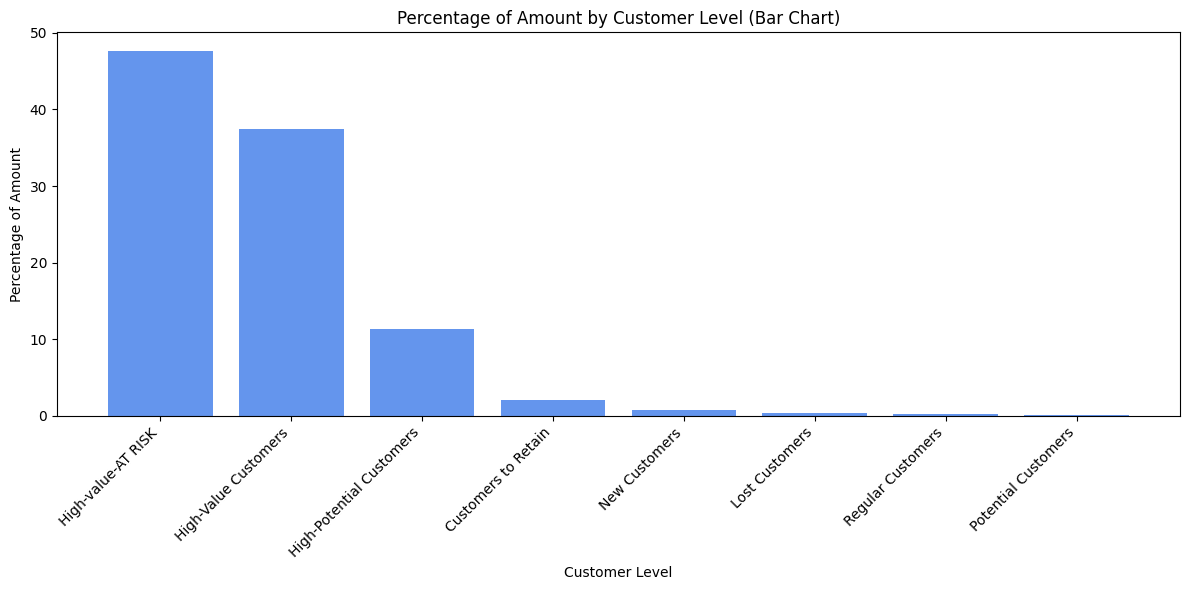

In [53]:
# Bar Graph Notebook

import pandas as pd
import matplotlib.pyplot as plt

# Data
data = {
    "Customer Level": [
        "High-value-AT RISK",
        "High-Value Customers",
        "High-Potential Customers",
        "Customers to Retain",
        "New Customers",
        "Lost Customers",
        "Regular Customers",
        "Potential Customers"
    ],
    "Percentage_of_Amount": [47.68, 37.42, 11.32, 2.07, 0.83, 0.37, 0.19, 0.12]
}

df = pd.DataFrame(data)

# Sort values
df = df.sort_values(by="Percentage_of_Amount", ascending=False)

# Bar Chart
plt.figure(figsize=(12,6))
plt.bar(df["Customer Level"], df["Percentage_of_Amount"], color='cornflowerblue')

plt.title("Percentage of Amount by Customer Level (Bar Chart)")
plt.xlabel("Customer Level")
plt.ylabel("Percentage of Amount")

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

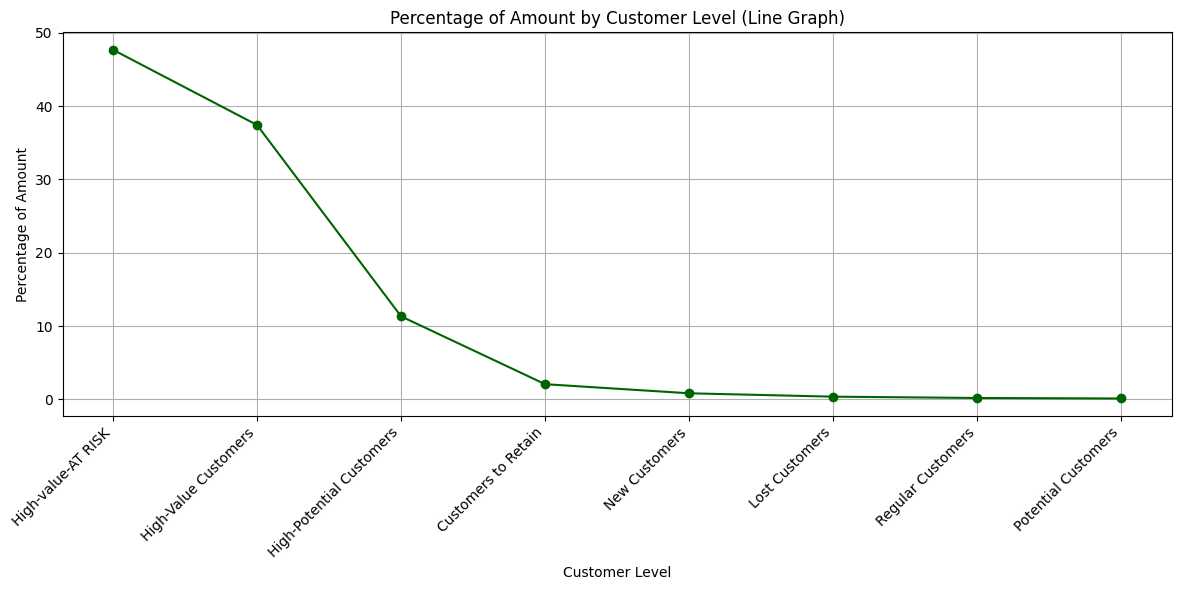

In [54]:
# Line Graph Notebook

import pandas as pd
import matplotlib.pyplot as plt

# Data
data = {
    "Customer Level": [
        "High-value-AT RISK",
        "High-Value Customers",
        "High-Potential Customers",
        "Customers to Retain",
        "New Customers",
        "Lost Customers",
        "Regular Customers",
        "Potential Customers"
    ],
    "Percentage_of_Amount": [47.68, 37.42, 11.32, 2.07, 0.83, 0.37, 0.19, 0.12]
}

df = pd.DataFrame(data)

# Sort values
df = df.sort_values(by="Percentage_of_Amount", ascending=False)

# Line Chart
plt.figure(figsize=(12,6))
plt.plot(df["Customer Level"], df["Percentage_of_Amount"], marker='o', color='darkgreen')

plt.title("Percentage of Amount by Customer Level (Line Graph)")
plt.xlabel("Customer Level")
plt.ylabel("Percentage of Amount")

plt.xticks(rotation=45, ha='right')
plt.grid(True)
plt.tight_layout()
plt.show()

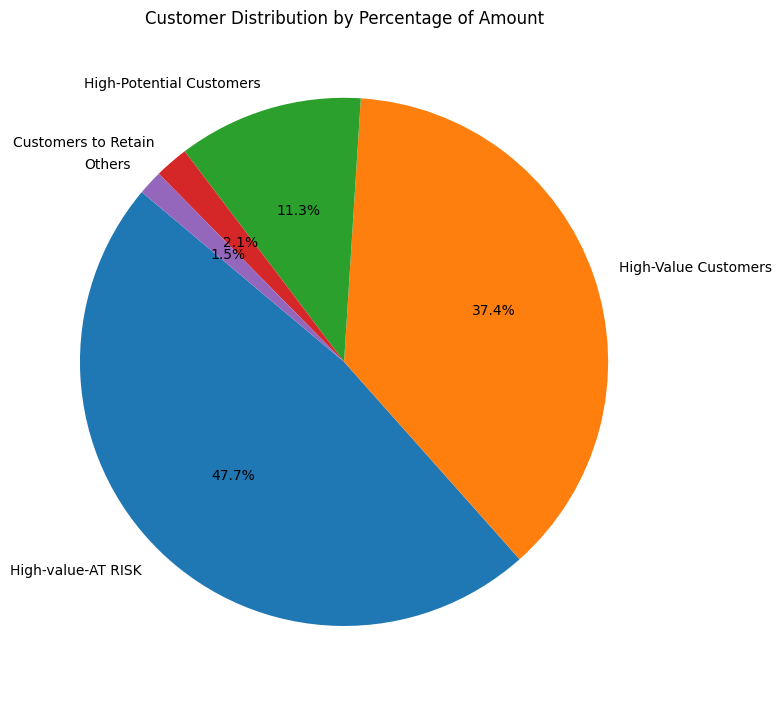

In [55]:
# Pie Chart Notebook

import pandas as pd
import matplotlib.pyplot as plt

# Data
data = {
    "Customer Level": [
        "High-value-AT RISK",
        "High-Value Customers",
        "High-Potential Customers",
        "Customers to Retain",
        "New Customers",
        "Lost Customers",
        "Regular Customers",
        "Potential Customers"
    ],
    "Percentage_of_Amount": [47.68, 37.42, 11.32, 2.07, 0.83, 0.37, 0.19, 0.12]
}

df = pd.DataFrame(data)

# Optional: group very small values into "Others"
threshold = 1
small = df[df["Percentage_of_Amount"] < threshold]
large = df[df["Percentage_of_Amount"] >= threshold]

if not small.empty:
    others_sum = small["Percentage_of_Amount"].sum()
    df_pie = pd.concat([
        large,
        pd.DataFrame({
            "Customer Level": ["Others"],
            "Percentage_of_Amount": [others_sum]
        })
    ])
else:
    df_pie = df

# Pie Chart
plt.figure(figsize=(8,8))
plt.pie(
    df_pie["Percentage_of_Amount"],
    labels=df_pie["Customer Level"],
    autopct='%1.1f%%',
    startangle=140
)

plt.title("Customer Distribution by Percentage of Amount")
plt.tight_layout()
plt.show()